In [372]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Fusion des sources de données

In [373]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 300)

In [374]:
# Concaténation des datasets

df_2022_2023_API = pd.read_csv("dataset/part1/ligue1_2022_completed.csv")
df_2023_2024_API = pd.read_csv("dataset/part1/ligue1_2023_completed.csv")
df_2024_2025_API = pd.read_csv("dataset/part1/ligue1_2024_completed.csv")

df_2022_2023 = pd.read_csv('dataset/part2/2022_2023.csv')
df_2023_2024 = pd.read_csv('dataset/part2/2023_2024.csv')
df_2024_2025 = pd.read_csv('dataset/part2/2024_2025.csv')
df_2025_2026 = pd.read_csv('dataset/part2/2025_2026.csv')

dataset1 = pd.concat([
    df_2022_2023_API, 
    df_2023_2024_API, 
    df_2024_2025_API
])

dataset2 = pd.concat([
    df_2022_2023, 
    df_2023_2024, 
    df_2024_2025, 
    df_2025_2026
])

In [375]:
# Harmonisation des dates

dataset1['Date'] = pd.to_datetime(dataset1['fixture.date']).dt.date
dataset2['Date'] = pd.to_datetime(dataset2['Date'], dayfirst=True).dt.date

In [376]:
# Harmonisation du nom des équipes

dataset2.replace(to_replace='Clermont', value='Clermont Foot', inplace=True)
dataset2.replace(to_replace='Troyes', value='Estac Troyes', inplace=True)
dataset2.replace(to_replace='Brest', value='Stade Brestois', inplace=True)

dataset1.replace(to_replace='Saint Etienne', value='St Etienne', inplace=True)
dataset1.replace(to_replace='Paris Saint Germain', value='Paris SG', inplace=True)
dataset1.replace(to_replace='Stade Brestois 29', value='Stade Brestois', inplace=True)

pd.DataFrame([dataset1['teams.home.name'].unique(), dataset2['HomeTeam'].unique()])

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
0,Lyon,Strasbourg,Clermont Foot,Toulouse,Angers,Lille,Montpellier,Lens,Rennes,Marseille,Nantes,Monaco,Paris SG,Reims,Ajaccio,Auxerre,Estac Troyes,Nice,Stade Brestois,Lorient,Metz,Le Havre,St Etienne,None
1,Lyon,Strasbourg,Clermont Foot,Toulouse,Angers,Lens,Lille,Montpellier,Rennes,Marseille,Nantes,Monaco,Paris SG,Ajaccio,Auxerre,Reims,Estac Troyes,Nice,Stade Brestois,Lorient,Metz,Le Havre,St Etienne,Paris FC


In [377]:
# Renommage des colonnes

dataset1.rename(columns={
    "fixture.referee":"Referee",
    "league.round": "Round", 
    "teams.home.name":"HomeTeam",
    "teams.away.name":"AwayTeam",
    "score.fulltime.home":"HomeScore", 
    "score.fulltime.away":"AwayScore"
}, inplace=True)

dataset2.rename(columns={
    "FTHG":"HomeScore",
    "FTAG":"AwayScore",
    "FTR": "Result",
    "HS":"HomeShot",
    "AS":"AwayShot",
    "HST":"HomeShotTarget",
    "AST":"AwayShotTarget",
    "HTHG":"HalftimeHomeGoals",
    "HTAG":"HalftimeAwayGoals",
    "HTR": "HalftimeResult",
    "HF": "HomeTeamFouls",
    "AF": "AwayTeamFouls",
    "HC":"HomeTeamCorners",
    "AC": "AwayTeamCorners",
    "HY": "HomeYellowCards",
    "AY":"AwayYellowCards",
    "HR":"HomeRedCards",
    "AR": "AwayRedCards"
}, inplace=True)

In [378]:
# Fusion des deux dataset

merged_df = pd.merge(
    dataset1,
    dataset2,
    # les clefs de fusion ne seront pas dédoublées
    left_on=['Date', 'HomeTeam', 'AwayTeam', 'HomeScore', 'AwayScore'],
    right_on=['Date', 'HomeTeam', 'AwayTeam', 'HomeScore', 'AwayScore'],
    how='outer'
)

# merged_df.head()
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1229 entries, 0 to 1228
Columns: 197 entries, fixture.id to LBCA
dtypes: float64(171), int64(2), object(24)
memory usage: 1.8+ MB


In [379]:
# Vérification des doublons

duplicated = merged_df[merged_df.duplicated()]
duplicated

,fixture.id,Referee,fixture.timezone,fixture.date,fixture.timestamp,fixture.periods.first,fixture.periods.second,fixture.venue.id,fixture.venue.name,fixture.venue.city,fixture.status.long,fixture.status.short,fixture.status.elapsed,fixture.status.extra,league.id,league.name,league.country,league.logo,league.flag,league.season,Round,league.standings,teams.home.id,HomeTeam,teams.home.logo,teams.home.winner,teams.away.id,AwayTeam,teams.away.logo,teams.away.winner,goals.home,goals.away,score.halftime.home,score.halftime.away,HomeScore,AwayScore,score.extratime.home,score.extratime.away,score.penalty.home,score.penalty.away,Date,Div,Time,Result,HalftimeHomeGoals,HalftimeAwayGoals,HalftimeResult,HomeShot,AwayShot,HomeShotTarget,AwayShotTarget,HomeTeamFouls,AwayTeamFouls,HomeTeamCorners,AwayTeamCorners,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards,B365H,B365D,B365A,BWH,BWD,BWA,IWH,IWD,IWA,PSH,PSD,PSA,WHH,WHD,WHA,VCH,VCD,VCA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,B365>2.5,B365<2.5,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,AHh,B365AHH,B365AHA,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,B365CH,B365CD,B365CA,BWCH,BWCD,BWCA,IWCH,IWCD,IWCA,PSCH,PSCD,PSCA,WHCH,WHCD,WHCA,VCCH,VCCD,VCCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFH,BFD,BFA,1XBH,1XBD,1XBA,BFEH,BFED,BFEA,BFE>2.5,BFE<2.5,BFEAHH,BFEAHA,BFCH,BFCD,BFCA,1XBCH,1XBCD,1XBCA,BFECH,BFECD,BFECA,BFEC>2.5,BFEC<2.5,BFECAHH,BFECAHA,BFDH,BFDD,BFDA,BMGMH,BMGMD,BMGMA,BVH,BVD,BVA,CLH,CLD,CLA,LBH,LBD,LBA,BFDCH,BFDCD,BFDCA,BMGMCH,BMGMCD,BMGMCA,BVCH,BVCD,BVCA,CLCH,CLCD,CLCA,LBCH,LBCD,LBCA


In [380]:
# for col in merged_df.select_dtypes('object'):
#     print(merged_df[col].value_counts())

In [381]:
# Nettoyage de la saison

merged_df['Round'] = merged_df['Round'].str.replace('Regular Season - ', '')
merged_df['Round'] = merged_df['Round'].str.replace('Relegation Round', '35')

In [382]:
# Calcul des données manquantes

def missing_values():
    missing_values = merged_df.isnull().sum()
    missing_percent = (missing_values / len(merged_df)) * 100

    missing_df = pd.DataFrame({
        'Colonne': missing_values.index,
        'Valeurs manquantes': missing_values.values,
        'Pourcentage': missing_percent.values
    })

    missing_df = missing_df[missing_df['Valeurs manquantes'] > 0].sort_values("Pourcentage", ascending=False)
    return missing_df

In [383]:
# Suppression des valeurs NaN ou identiques sur tout le dataset

merged_df.drop([
    'fixture.id', 
    'fixture.timezone', 
    'fixture.date',
    'fixture.timestamp', 
    'fixture.periods.first',
    'fixture.periods.second',
    'fixture.venue.id',
    'fixture.venue.name',
    'fixture.venue.city',
    'fixture.status.long',
    'fixture.status.short',
    'fixture.status.elapsed',
    'fixture.status.extra',
    'league.id',
    'league.name',
    'league.country',
    'league.logo',
    'league.flag',
    'league.standings',
    'teams.home.id',
    'teams.home.logo',
    'teams.away.id',
    'teams.home.winner',
    'teams.away.logo',
    'teams.away.winner',
    'Div',
    "score.penalty.home", 
    "score.penalty.away", 
    "score.extratime.home", 
    "score.extratime.away", 
    "LBCA", 
    "LBCD", 
    "LBCH", 
    "CLCA", 
    "CLCD", 
    "CLCH", 
    "LBA", 
    "CLH", 
    "CLD", 
    "LBH", 
    "LBD", 
    "CLA", 
    "BMGMCH", 
    "BVA", 
    "BFDH", 
    "BFDD", 
    "BFDA", 
    "BFDCA", 
    "BMGMD", 
    "BMGMA", 
    "BVH", 
    "BVD", 
    "BMGMH", 
    "BVCA", 
    "BVCH", 
    "BMGMCA", 
    "BMGMCD", 
    "BFDCH", 
    "BFDCD", 
    "BVCD", 
    "1XBA", 
    "1XBH", 
    "1XBD", 
    "1XBCH", 
    "BFCA", 
    "BFCD", 
    "BFCH", 
    "BFD", 
    "BFA", 
    "BFH", 
    "1XBCA", 
    "1XBCD",
    "IWD", 
    "IWA", 
    "IWCH", 
    "IWCD", 
    "IWCA", 
    "IWH", 
    "BFE<2.5", 
    "BFE>2.5", 
    "BFEAHA", 
    "BFEAHH", 
    "BFED", 
    "BFEH", 
    "BFECAHA", 
    "BFEA", 
    "BFECA", 
    "BFECAHH", 
    "BFECH", 
    "BFEC>2.5", 
    "BFEC<2.5", 
    "BFECD", 
    "VCA", 
    "VCD", 
    "VCH", 
    "VCCH", 
    "VCCA", 
    "VCCD", 
    "WHA", 
    "WHD", 
    "WHH", 
    "WHCD", 
    "WHCH", 
    "WHCA",
    "goals.home",
    "goals.away",
    "score.halftime.home",
    "score.halftime.away"
], axis=1, inplace=True)

In [384]:
# Remplacement de l'année de la dernière saison qui manque 

merged_df['league.season'] = merged_df['league.season'].fillna('2025')
merged_df['league.season'] = merged_df['league.season'].fillna('2025')
merged_df.tail()

,Referee,league.season,Round,HomeTeam,AwayTeam,HomeScore,AwayScore,Date,Time,Result,HalftimeHomeGoals,HalftimeAwayGoals,HalftimeResult,HomeShot,AwayShot,HomeShotTarget,AwayShotTarget,HomeTeamFouls,AwayTeamFouls,HomeTeamCorners,AwayTeamCorners,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards,B365H,B365D,B365A,BWH,BWD,BWA,PSH,PSD,PSA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,B365>2.5,B365<2.5,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,AHh,B365AHH,B365AHA,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,B365CH,B365CD,B365CA,BWCH,BWCD,BWCA,PSCH,PSCD,PSCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
1224,NaN,2025,NaN,Monaco,Stade Brestois,2,0,2026-03-14,20:05,H,1.0,0.0,H,10.0,13.0,4.0,1.0,9.0,8.0,3.0,8.0,2.0,1.0,0.0,0.0,1.67,4.2,4.50,1.68,4.1,4.60,NaN,NaN,NaN,1.70,4.2,5.00,1.64,4.03,4.67,1.62,2.30,NaN,NaN,1.65,2.30,1.61,2.22,-0.75,1.85,2.00,NaN,NaN,1.85,2.02,1.79,1.98,1.57,4.1,5.50,1.62,4.20,5.00,NaN,NaN,NaN,1.62,4.2,5.5,1.58,4.14,5.23,1.67,2.20,NaN,NaN,1.67,2.30,1.62,2.20,-1.00,2.00,1.85,NaN,NaN,2.07,1.85,1.99,1.79
1225,NaN,2025,NaN,Le Havre,Lyon,0,0,2026-03-15,16:15,D,0.0,0.0,D,12.0,13.0,4.0,4.0,7.0,16.0,2.0,2.0,1.0,3.0,1.0,0.0,3.75,3.4,2.00,3.60,3.4,2.05,NaN,NaN,NaN,3.85,3.5,2.05,3.67,3.37,1.99,2.10,1.73,NaN,NaN,2.10,1.75,2.04,1.72,0.50,1.80,2.05,NaN,NaN,1.80,2.05,1.77,1.94,3.40,3.3,2.15,3.40,3.30,2.15,NaN,NaN,NaN,3.60,3.4,2.2,3.44,3.33,2.11,2.10,1.73,NaN,NaN,2.10,1.80,2.02,1.74,0.25,2.00,1.85,NaN,NaN,2.18,1.85,2.01,1.78
1226,NaN,2025,NaN,Metz,Toulouse,3,4,2026-03-15,16:15,A,2.0,3.0,A,17.0,19.0,8.0,6.0,10.0,13.0,4.0,4.0,0.0,3.0,0.0,0.0,4.00,3.4,1.95,3.90,3.3,2.00,NaN,NaN,NaN,4.00,3.4,2.00,3.84,3.30,1.97,2.20,1.67,NaN,NaN,2.20,1.67,2.13,1.66,0.50,1.88,1.98,NaN,NaN,1.88,1.98,1.79,1.92,4.00,3.4,1.95,3.90,3.40,1.98,NaN,NaN,NaN,4.00,3.4,2.0,3.92,3.36,1.96,2.20,1.67,NaN,NaN,2.20,1.73,2.14,1.67,0.50,1.88,1.98,NaN,NaN,1.88,1.98,1.81,1.91
1227,NaN,2025,NaN,Rennes,Lille,1,2,2026-03-15,19:45,A,0.0,1.0,A,12.0,8.0,4.0,3.0,16.0,7.0,5.0,2.0,2.0,5.0,0.0,0.0,2.20,3.4,3.25,2.25,3.4,3.20,NaN,NaN,NaN,2.25,3.4,3.33,2.22,3.34,3.12,1.80,2.00,NaN,NaN,1.86,2.00,1.79,1.95,-0.25,1.93,1.93,NaN,NaN,1.93,1.93,1.88,1.88,2.20,3.3,3.40,2.20,3.25,3.30,NaN,NaN,NaN,2.25,3.4,3.4,2.19,3.26,3.30,1.91,1.91,NaN,NaN,2.05,1.91,1.95,1.80,-0.25,1.93,1.93,NaN,NaN,1.93,1.93,1.88,1.88
1228,NaN,2025,NaN,Strasbourg,Paris FC,0,0,2026-03-15,14:00,D,0.0,0.0,D,12.0,11.0,3.0,2.0,11.0,17.0,12.0,4.0,1.0,0.0,0.0,0.0,1.75,3.7,4.75,1.75,3.9,4.40,NaN,NaN,NaN,1.78,4.0,4.75,1.73,3.75,4.39,1.83,2.03,NaN,NaN,1.83,2.03,1.77,1.98,-0.75,2.00,1.85,NaN,NaN,2.00,1.90,1.94,1.83,1.70,3.9,5.00,1.66,4.00,4.80,NaN,NaN,NaN,1.70,4.2,5.0,1.65,3.93,4.88,1.73,2.10,NaN,NaN,1.73,2.20,1.71,2.07,-0.75,1.88,1.98,NaN,NaN,1.95,2.05,1.85,1.92


In [385]:
# Les matchs sans score n'ont aucune valeur, on les supprime

merged_df = merged_df.dropna(subset=['Result'])

In [386]:
# Imputation des arbitres et des Round manquants

referees_df = pd.read_csv('dataset/referees_list.csv')
referees_df["Round"] = referees_df["Round"].astype(str)
referees_df['Date'] = pd.to_datetime(referees_df['Date']).dt.date

referees_df.head()

final_df = pd.merge(
    merged_df,
    referees_df,
    left_on=['Date', 'HomeTeam'],
    right_on=['Date', 'HomeTeam'],
    how='left', suffixes=('','_new')
)

final_df['Referee'] = final_df['Referee'].fillna(final_df['Referee_new'])
final_df['Round'] = final_df['Round'].fillna(final_df['Round_new'])

final_df.drop(['Referee_new', 'Round_new'], axis = 1, inplace=True)
final_df["Round"] = final_df["Round"].astype(int)
final_df.info()

merged_df = final_df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1225 entries, 0 to 1224
Data columns (total 89 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Referee            1225 non-null   object 
 1   league.season      1225 non-null   object 
 2   Round              1225 non-null   int64  
 3   HomeTeam           1225 non-null   object 
 4   AwayTeam           1225 non-null   object 
 5   HomeScore          1225 non-null   int64  
 6   AwayScore          1225 non-null   int64  
 7   Date               1225 non-null   object 
 8   Time               1225 non-null   object 
 9   Result             1225 non-null   object 
 10  HalftimeHomeGoals  1225 non-null   float64
 11  HalftimeAwayGoals  1225 non-null   float64
 12  HalftimeResult     1225 non-null   object 
 13  HomeShot           1225 non-null   float64
 14  AwayShot           1225 non-null   float64
 15  HomeShotTarget     1225 non-null   float64
 16  AwayShotTarget     1225 

In [387]:
# Affichage des données manquantes

missing_values()

,Colonne,Valeurs manquantes,Pourcentage
28,BWH,126,10.285714
29,BWD,126,10.285714
62,BWCA,126,10.285714
61,BWCD,126,10.285714
60,BWCH,126,10.285714
30,BWA,126,10.285714
42,P>2.5,87,7.102041
43,P<2.5,87,7.102041
74,PC>2.5,85,6.938776
75,PC<2.5,85,6.938776


In [388]:
# Imputation par la médiane des données manquantes

features_to_replace = {'BWH', 'BWD', 'BWA', 'PSH', 'PSD', 'PSA', 'P>2.5', 'P<2.5', 'PAHH', 'PAHA', 'BWCH', 'BWCD', 'BWCA', 'PSCH', 'PSCD', 'PSCA', 'PC>2.5', 'PC<2.5', 'PCAHH', 'PCAHA'}

for feat in features_to_replace:
    median = merged_df[feat].median()
    merged_df[feat] = merged_df[feat].fillna(median)

merged_df.head()

,Referee,league.season,Round,HomeTeam,AwayTeam,HomeScore,AwayScore,Date,Time,Result,HalftimeHomeGoals,HalftimeAwayGoals,HalftimeResult,HomeShot,AwayShot,HomeShotTarget,AwayShotTarget,HomeTeamFouls,AwayTeamFouls,HomeTeamCorners,AwayTeamCorners,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards,B365H,B365D,B365A,BWH,BWD,BWA,PSH,PSD,PSA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,B365>2.5,B365<2.5,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,AHh,B365AHH,B365AHA,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,B365CH,B365CD,B365CA,BWCH,BWCD,BWCA,PSCH,PSCD,PSCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA
0,B. Bastien,2022.0,1,Lyon,Ajaccio,2,1,2022-08-05,20:00,H,2.0,1.0,H,11.0,8.0,6.0,4.0,10.0,18.0,4.0,3.0,1.0,6.0,1.0,1.0,1.33,5.25,8.50,1.33,5.25,8.00,1.33,5.53,10.75,1.36,5.70,11.00,1.32,5.35,9.65,1.66,2.20,1.70,2.26,1.74,2.31,1.68,2.21,-1.50,2.00,1.93,2.01,1.91,2.04,1.94,1.97,1.89,1.33,5.00,8.50,1.35,5.25,7.50,1.38,5.31,8.68,1.38,5.70,10.00,1.34,5.21,8.96,1.66,2.20,1.70,2.27,1.72,2.47,1.64,2.27,-1.50,2.08,1.85,2.12,1.81,2.12,1.96,2.01,1.86
1,J. Stinat,2022.0,1,Clermont Foot,Paris SG,0,5,2022-08-06,20:00,A,0.0,3.0,A,7.0,18.0,1.0,12.0,13.0,13.0,0.0,6.0,2.0,1.0,0.0,0.0,9.50,6.50,1.25,10.00,6.50,1.25,9.88,6.81,1.28,11.50,7.00,1.30,10.06,6.53,1.26,1.40,3.00,1.41,3.04,1.43,3.25,1.38,3.00,1.75,1.99,1.94,1.95,1.95,2.01,1.95,1.96,1.90,13.00,7.00,1.20,13.00,7.00,1.21,13.32,6.77,1.24,14.50,7.40,1.29,12.17,6.67,1.23,1.40,3.00,1.45,2.85,1.47,3.00,1.42,2.87,2.00,1.94,1.99,1.93,1.98,1.95,2.17,1.83,2.02
2,F. Letexier,2022.0,1,Strasbourg,Monaco,1,2,2022-08-06,16:00,A,0.0,1.0,A,11.0,24.0,7.0,11.0,18.0,15.0,3.0,7.0,0.0,2.0,0.0,0.0,2.62,3.25,2.75,2.60,3.30,2.70,2.64,3.40,2.86,2.70,3.56,2.92,2.60,3.36,2.75,2.03,1.87,2.07,1.85,2.09,1.98,1.97,1.85,0.00,1.91,2.02,1.88,2.05,1.93,2.06,1.88,2.00,2.30,3.20,3.20,2.40,3.20,3.00,2.42,3.35,3.26,2.62,3.52,3.28,2.43,3.23,3.08,2.20,1.66,2.12,1.79,2.22,1.98,2.12,1.74,-0.25,2.03,1.90,2.07,1.87,2.13,1.90,2.06,1.82
3,H. Ben El Hadj,2022.0,1,Angers,Nantes,0,0,2022-08-07,14:00,D,0.0,0.0,D,16.0,14.0,6.0,4.0,15.0,13.0,3.0,6.0,3.0,3.0,0.0,0.0,2.70,3.25,2.70,2.65,3.20,2.70,2.82,3.29,2.75,2.84,3.30,2.82,2.73,3.22,2.71,2.10,1.72,2.23,1.72,2.23,1.80,2.13,1.72,0.00,1.97,1.96,1.99,1.93,1.99,1.98,1.94,1.92,3.00,3.25,2.37,3.10,3.10,2.40,3.22,3.28,2.46,3.29,3.35,2.50,3.11,3.21,2.41,2.20,1.66,2.23,1.72,2.24,1.76,2.17,1.70,0.25,1.85,2.08,1.83,2.09,1.87,2.12,1.81,2.07
4,T. Léonard,2022.0,1,Lens,Stade Brestois,3,2,2022-08-07,14:00,H,1.0,0.0,H,17.0,6.0,7.0,4.0,16.0,14.0,6.0,3.0,2.0,4.0,0.0,0.0,1.57,4.33,5.25,1.53,4.40,5.75,1.60,4.60,5.51,1.60,4.70,6.00,1.56,4.43,5.54,1.66,2.20,1.69,2.28,1.73,2.31,1.66,2.23,-1.00,1.98,1.95,1.99,1.93,1.99,1.97,1.93,1.92,1.60,4.20,5.25,1.62,3.90,5.50,1.62,4.23,5.81,1.65,4.30,5.90,1.61,4.07,5.53,1.89,2.01,1.87,2.05,1.90,2.12,1.83,1.99,-1.00,2.07,1.86,2.10,1.83,2.13,1.87,2.07,1.81


In [389]:
# Affichage des données manquantes

missing_values()

,Colonne,Valeurs manquantes,Pourcentage


In [390]:
# Encodage temporaire pour la matrice de corrélation
# merged_df.info()

# merged_df.head()

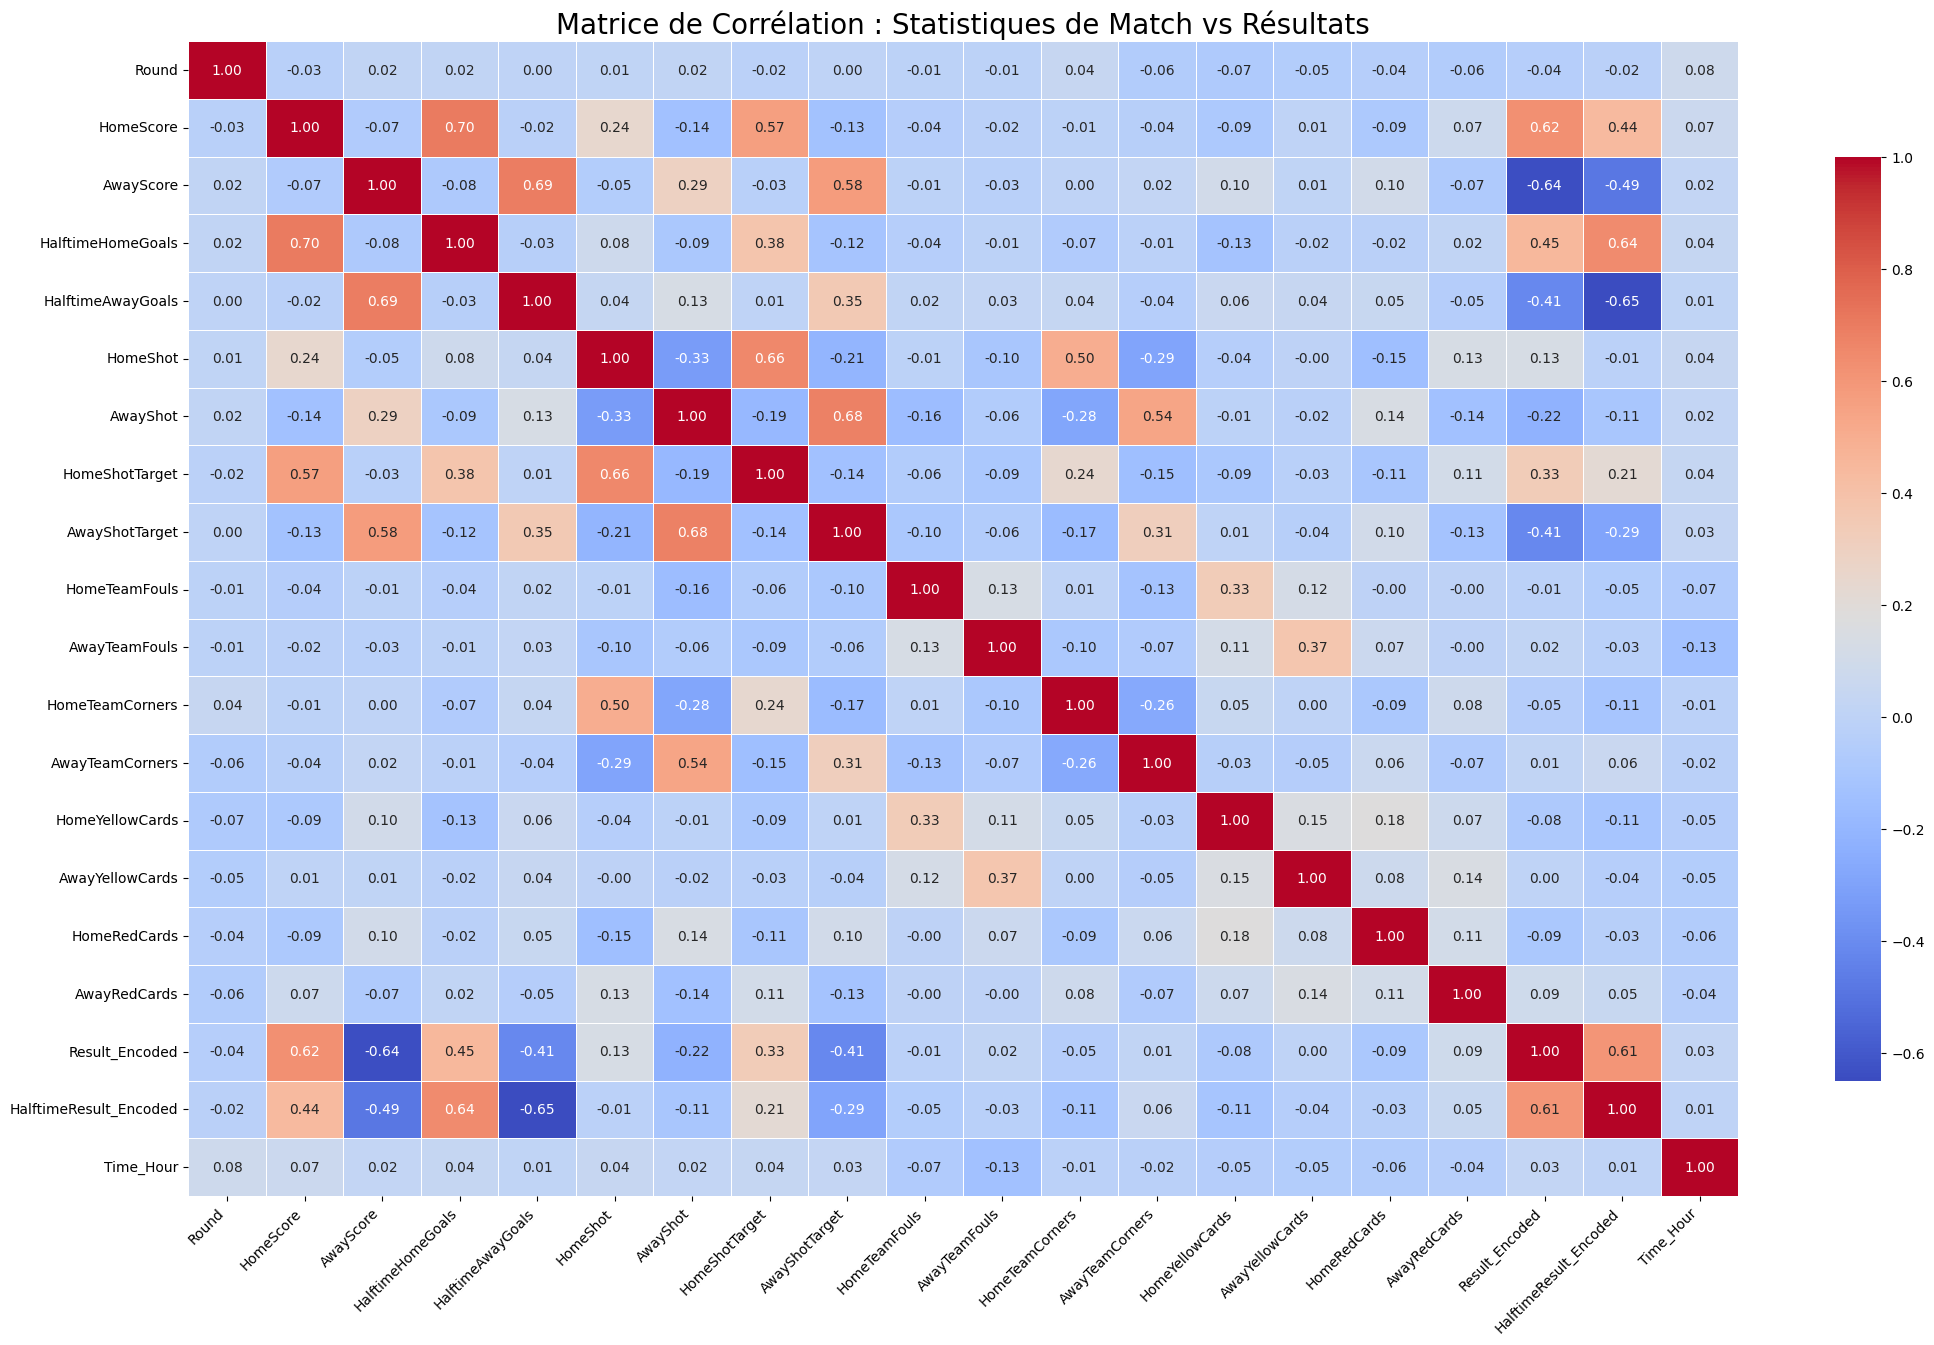

In [391]:
# Création d'un dataset temporaire pour la heatmap

# Encodages temporaires
merged_df['Result_Encoded'] = merged_df['Result'].map({'H': 2, 'D': 1, 'A': 0})
merged_df['HalftimeResult_Encoded'] = merged_df['HalftimeResult'].map({'H': 2, 'D': 1, 'A': 0})
merged_df['Time_Hour'] = pd.to_datetime(merged_df['Time'], format='%H:%M').dt.hour

df_heatmap = merged_df.drop(['Referee', 'HomeTeam', 'AwayTeam', 'Date', 'Result', 'Time', 'HalftimeResult'], axis=1)

cols_stats = df_heatmap.loc[:, : 'AwayRedCards']
cols_targets = df_heatmap.iloc[:, -3:] # Récupère Result_Encoded, HalftimeResult_Encoded et Time_Hour

df_heatmap = pd.concat([cols_stats, cols_targets], axis=1)

# Selection des variables numérique uniquement
df_heatmap = df_heatmap.select_dtypes(include=[np.number])

corr_matrix = df_heatmap.corr()

# 5. Affichage du graphique
plt.figure(figsize=(25, 15))

sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            fmt='.2f', 
            linewidths=0.5,
            cbar_kws={"shrink": .8})

plt.title('Matrice de Corrélation : Statistiques de Match vs Résultats', fontsize=20)
plt.xticks(rotation=45, ha='right')
plt.show()

## Analyse univariée

In [392]:
# Analyse des variables numériques

numeric_values = [
    'league.season', 
    'Round', 
    'HomeScore', 
    'AwayScore', 
    'HalftimeHomeGoals', 
    'HalftimeAwayGoals',
    'HomeShot',
    'AwayShot',
    'HomeShotTarget',
    'AwayShotTarget',
    'HomeTeamFouls',
    'AwayTeamFouls',
    'HomeTeamCorners',
    'AwayTeamCorners',
    'HomeYellowCards',
    'AwayYellowCards',
    'HomeRedCards',
    'AwayRedCards',
    'Result_Encoded', # 2=Home, 1=Draw, 0=Away
    'HalftimeResult_Encoded',
]

# Statistiques complètes
numeric_stats = merged_df[numeric_values].describe()

# Analyse des distributions
for var in numeric_stats:
    print(f"\n🔹 {var.upper()}:")
    print(f"   Moyenne: {merged_df[var].mean():.2f}")
    print(f"   Médiane: {merged_df[var].median():.2f}")
    print(f"   Écart-type: {merged_df[var].std():.2f}")
    print(f"   Asymétrie (skew): {merged_df[var].skew():.2f}")
    print(f"   Aplatissement (kurtosis): {merged_df[var].kurtosis():.2f}")

# numeric_stats


🔹 ROUND:
   Moyenne: 17.35
   Médiane: 17.00
   Écart-type: 10.02
   Asymétrie (skew): 0.13
   Aplatissement (kurtosis): -1.06

🔹 HOMESCORE:
   Moyenne: 1.53
   Médiane: 1.00
   Écart-type: 1.29
   Asymétrie (skew): 0.95
   Aplatissement (kurtosis): 1.12

🔹 AWAYSCORE:
   Moyenne: 1.29
   Médiane: 1.00
   Écart-type: 1.20
   Asymétrie (skew): 1.08
   Aplatissement (kurtosis): 1.55

🔹 HALFTIMEHOMEGOALS:
   Moyenne: 0.67
   Médiane: 0.00
   Écart-type: 0.81
   Asymétrie (skew): 1.32
   Aplatissement (kurtosis): 2.61

🔹 HALFTIMEAWAYGOALS:
   Moyenne: 0.59
   Médiane: 0.00
   Écart-type: 0.80
   Asymétrie (skew): 1.50
   Aplatissement (kurtosis): 2.61

🔹 HOMESHOT:
   Moyenne: 13.43
   Médiane: 13.00
   Écart-type: 5.08
   Asymétrie (skew): 0.61
   Aplatissement (kurtosis): 0.70

🔹 AWAYSHOT:
   Moyenne: 11.36
   Médiane: 11.00
   Écart-type: 4.70
   Asymétrie (skew): 0.62
   Aplatissement (kurtosis): 0.49

🔹 HOMESHOTTARGET:
   Moyenne: 4.85
   Médiane: 5.00
   Écart-type: 2.46
   Asymétrie 

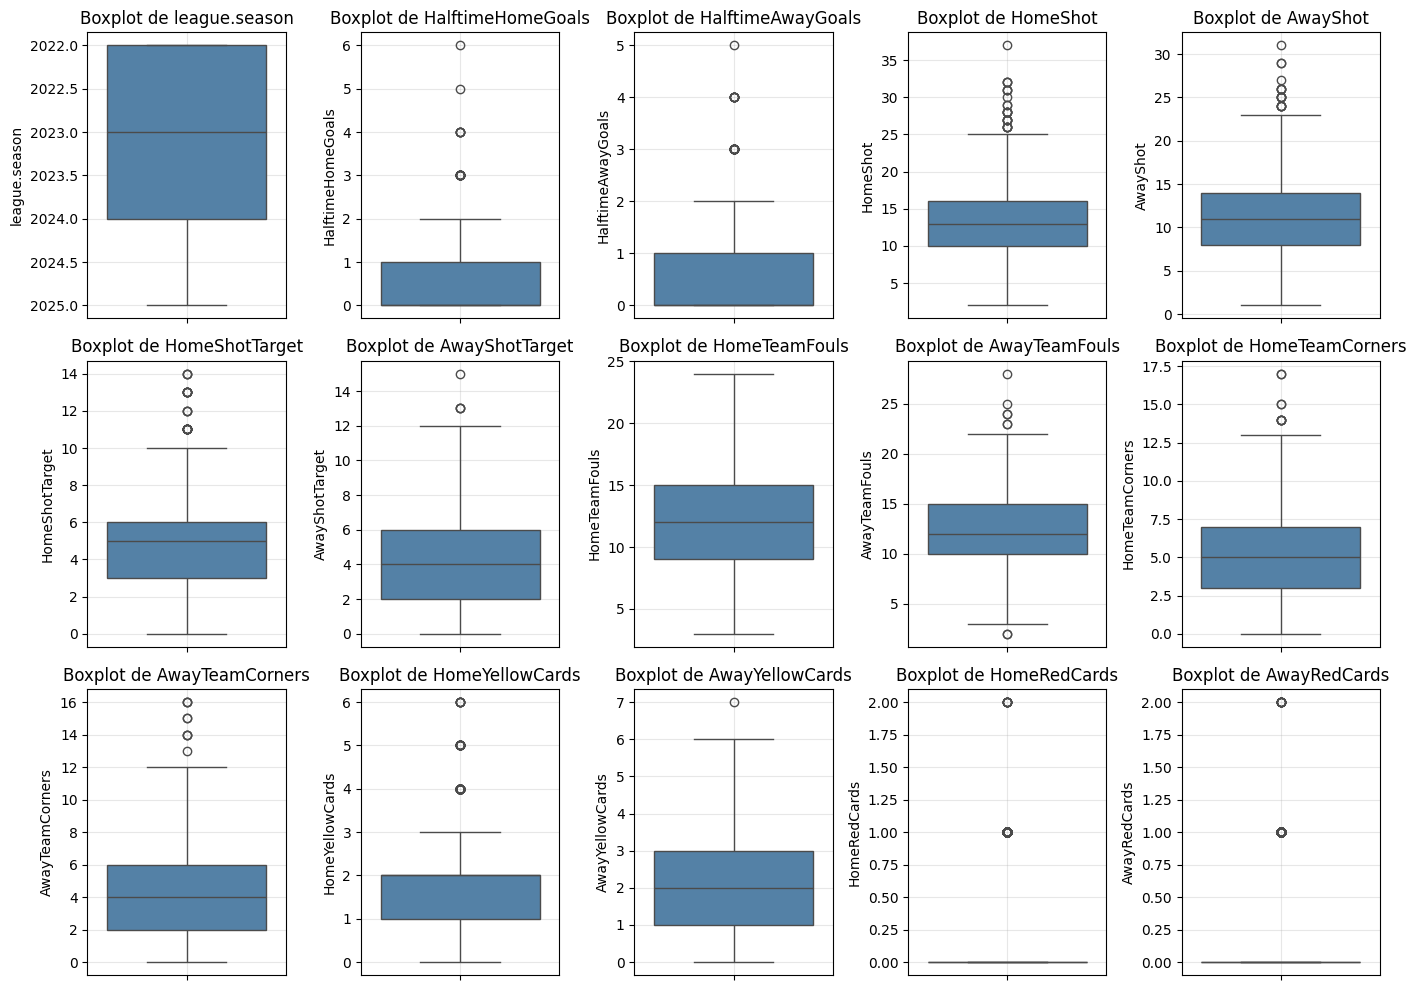

In [393]:
# Outliers des variables numériques

# Visualisons les distributions des variables numériques avec seaborn
numeric_cols = ["league.season", "HalftimeHomeGoals","HalftimeAwayGoals", "HomeShot", "AwayShot", "HomeShotTarget", "AwayShotTarget", "HomeTeamFouls", "AwayTeamFouls", "HomeTeamCorners", "AwayTeamCorners","HomeYellowCards", "AwayYellowCards", "HomeRedCards", "AwayRedCards"]
fig, axes = plt.subplots(3, 5, figsize=(14, 10))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(y=final_df[col], ax=axes[idx], color='steelblue')
    axes[idx].set_title(f'Boxplot de {col}')
    axes[idx].set_ylabel(col)
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [394]:
# Analyse des variables catégorielles

categorical_values = [
    'Time_Hour',
    'Date',
    'Referee'
] 

time_hour_unique = merged_df['Time_Hour'].unique()
referee_unique = merged_df['Referee'].unique()
date_unique = merged_df['Date'].unique()
date_unique_percent = 100 * merged_df['Date'].nunique() / len(merged_df['Date'])

print(f"Ratio de dates uniques : {date_unique_percent:.2f}%")

# print(f'Arbitres : {referee_unique}')
# print(f'Heures : {time_hour_unique}')
# print(f'Dates : {date_unique}')

for var in categorical_values:
    print(f"\n🔹 {var.upper()}:")
    counts = merged_df[var].value_counts()
    percentages = merged_df[var].value_counts(normalize=True) * 100
    
    result_df = pd.DataFrame({
        'Fréquence': counts,
        'Pourcentage': percentages.round(1)
    })
    display(result_df)

Ratio de dates uniques : 31.02%

🔹 TIME_HOUR:


,Fréquence,Pourcentage
Time_Hour,,
16,338,27.6
20,289,23.6
14,276,22.5
19,162,13.2
18,101,8.2
12,58,4.7
22,1,0.1



🔹 DATE:


,Fréquence,Pourcentage
Date,,
2023-05-27,10,0.8
2023-06-03,10,0.8
2022-08-31,10,0.8
2023-01-11,10,0.8
2023-02-01,10,0.8
...,...,...
2024-03-29,1,0.1
2024-04-05,1,0.1
2024-04-12,1,0.1



🔹 REFEREE:


,Fréquence,Pourcentage
Referee,,
W. Delajod,73,6.0
E. Wattellier,72,5.9
B. Bastien,70,5.7
J. Stinat,70,5.7
T. Léonard,69,5.6
J. Brisard,69,5.6
C. Turpin,67,5.5
J. Pignard,67,5.5
B. Millot,66,5.4


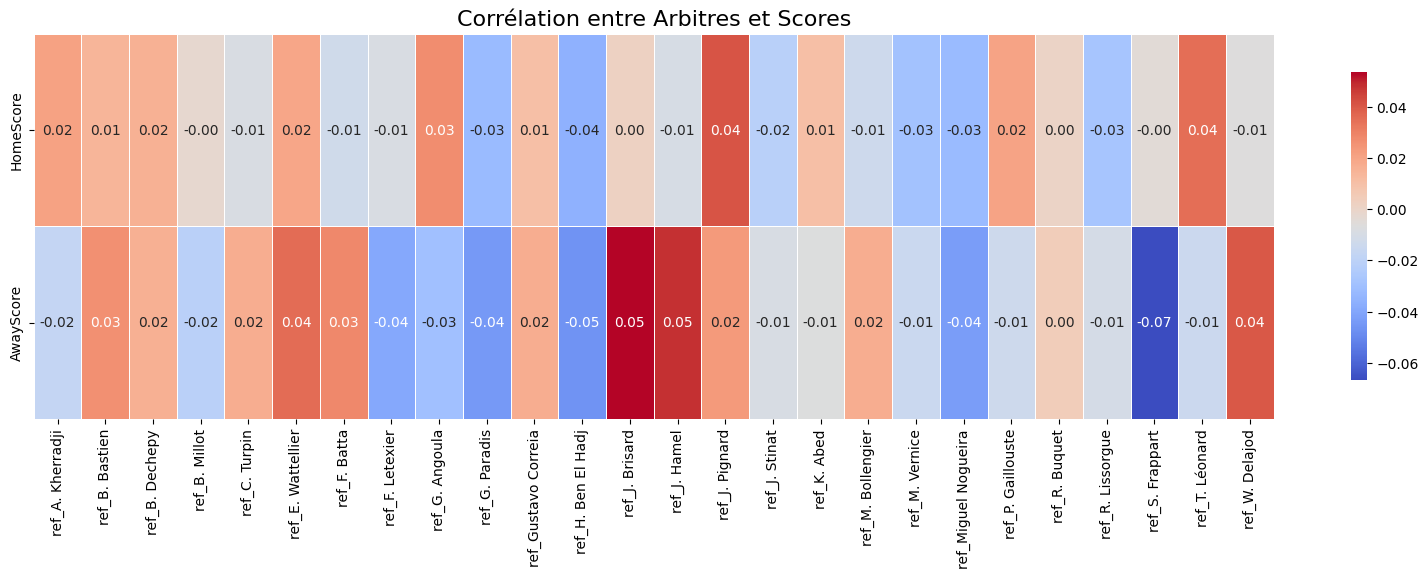

In [395]:
# Influence de l'arbitre

df_encoded = pd.get_dummies(merged_df, columns=['Referee'], prefix='ref')

cols_to_corr = ['HomeScore', 'AwayScore'] + [col for col in df_encoded.columns if col.startswith('ref_')]

df_referee_score = df_encoded[cols_to_corr]

corr_matrix = df_referee_score.corr()

score_vs_ref = corr_matrix.loc[['HomeScore', 'AwayScore'], [col for col in df_encoded.columns if col.startswith('ref_')]]

plt.figure(figsize=(20, 5)) # Format large pour bien lire les noms d'arbitres
sns.heatmap(score_vs_ref, 
            annot=True, 
            cmap='coolwarm', 
            fmt='.2f', 
            linewidths=0.5,
            cbar_kws={"shrink": .8})

plt.title('Corrélation entre Arbitres et Scores', fontsize=16)
plt.show()

In [396]:
# Moyenne de score par arbitre

mean_scores = merged_df.groupby('Referee')[['HomeScore', 'AwayScore']].mean()
overall_mean = merged_df[['HomeScore', 'AwayScore']].mean()

print("Moyenne par arbitre :\n", mean_scores)
print("\nMoyenne générale :\n", overall_mean)

Moyenne par arbitre :
                  HomeScore  AwayScore
Referee                              
A. Kherradji      1.703704   1.148148
B. Bastien        1.600000   1.414286
B. Dechepy        1.612903   1.370968
B. Millot         1.515152   1.181818
C. Turpin         1.477612   1.373134
E. Wattellier     1.625000   1.458333
F. Batta          1.441860   1.465116
F. Letexier       1.475410   1.081967
G. Angoula        1.741935   1.064516
G. Paradis        1.090909   0.727273
Gustavo Correia   2.000000   2.000000
H. Ben El Hadj    1.315789   1.035088
J. Brisard        1.536232   1.550725
J. Hamel          1.375000   2.000000
J. Pignard        1.746269   1.402985
J. Stinat         1.414286   1.242857
K. Abed           2.000000   1.000000
M. Bollengier     1.453125   1.375000
M. Vernice        1.351852   1.203704
Miguel Nogueira   0.500000   0.000000
P. Gaillouste     1.687500   1.187500
R. Buquet         1.529412   1.313725
R. Lissorgue      1.324324   1.216216
S. Frappart       1.500000 

In [397]:
# Encodage de la date et l'heure

def get_day_moment(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    else:
        return 'Evening'
    
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Sun'
    else:
        return 'Fall'
    
# Conversion des dates
merged_df['Date'] = pd.to_datetime(merged_df['Date'])

merged_df['Moment'] = merged_df['Time_Hour'].apply(get_day_moment)
merged_df['Saison'] = merged_df['Date'].dt.month.apply(get_season)

merged_df.drop(['Date', 'Time_Hour', 'Time', 'Result'], inplace=True, axis=1)

merged_df.tail()

,Referee,league.season,Round,HomeTeam,AwayTeam,HomeScore,AwayScore,HalftimeHomeGoals,HalftimeAwayGoals,HalftimeResult,HomeShot,AwayShot,HomeShotTarget,AwayShotTarget,HomeTeamFouls,AwayTeamFouls,HomeTeamCorners,AwayTeamCorners,HomeYellowCards,AwayYellowCards,HomeRedCards,AwayRedCards,B365H,B365D,B365A,BWH,BWD,BWA,PSH,PSD,PSA,MaxH,MaxD,MaxA,AvgH,AvgD,AvgA,B365>2.5,B365<2.5,P>2.5,P<2.5,Max>2.5,Max<2.5,Avg>2.5,Avg<2.5,AHh,B365AHH,B365AHA,PAHH,PAHA,MaxAHH,MaxAHA,AvgAHH,AvgAHA,B365CH,B365CD,B365CA,BWCH,BWCD,BWCA,PSCH,PSCD,PSCA,MaxCH,MaxCD,MaxCA,AvgCH,AvgCD,AvgCA,B365C>2.5,B365C<2.5,PC>2.5,PC<2.5,MaxC>2.5,MaxC<2.5,AvgC>2.5,AvgC<2.5,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,Result_Encoded,HalftimeResult_Encoded,Moment,Saison
1220,J. Pignard,2025,26,Monaco,Stade Brestois,2,0,1.0,0.0,H,10.0,13.0,4.0,1.0,9.0,8.0,3.0,8.0,2.0,1.0,0.0,0.0,1.67,4.2,4.50,1.68,4.1,4.60,2.27,3.76,3.33,1.70,4.2,5.00,1.64,4.03,4.67,1.62,2.30,1.83,2.06,1.65,2.30,1.61,2.22,-0.75,1.85,2.00,1.95,1.95,1.85,2.02,1.79,1.98,1.57,4.1,5.50,1.62,4.20,5.00,2.3,3.72,3.39,1.62,4.2,5.5,1.58,4.14,5.23,1.67,2.20,1.86,2.05,1.67,2.30,1.62,2.20,-1.00,2.00,1.85,1.95,1.97,2.07,1.85,1.99,1.79,2,2,Evening,Spring
1221,J. Stinat,2025,26,Le Havre,Lyon,0,0,0.0,0.0,D,12.0,13.0,4.0,4.0,7.0,16.0,2.0,2.0,1.0,3.0,1.0,0.0,3.75,3.4,2.00,3.60,3.4,2.05,2.27,3.76,3.33,3.85,3.5,2.05,3.67,3.37,1.99,2.10,1.73,1.83,2.06,2.10,1.75,2.04,1.72,0.50,1.80,2.05,1.95,1.95,1.80,2.05,1.77,1.94,3.40,3.3,2.15,3.40,3.30,2.15,2.3,3.72,3.39,3.60,3.4,2.2,3.44,3.33,2.11,2.10,1.73,1.86,2.05,2.10,1.80,2.02,1.74,0.25,2.00,1.85,1.95,1.97,2.18,1.85,2.01,1.78,1,1,Afternoon,Spring
1222,G. Angoula,2025,26,Metz,Toulouse,3,4,2.0,3.0,A,17.0,19.0,8.0,6.0,10.0,13.0,4.0,4.0,0.0,3.0,0.0,0.0,4.00,3.4,1.95,3.90,3.3,2.00,2.27,3.76,3.33,4.00,3.4,2.00,3.84,3.30,1.97,2.20,1.67,1.83,2.06,2.20,1.67,2.13,1.66,0.50,1.88,1.98,1.95,1.95,1.88,1.98,1.79,1.92,4.00,3.4,1.95,3.90,3.40,1.98,2.3,3.72,3.39,4.00,3.4,2.0,3.92,3.36,1.96,2.20,1.67,1.86,2.05,2.20,1.73,2.14,1.67,0.50,1.88,1.98,1.95,1.97,1.88,1.98,1.81,1.91,0,0,Afternoon,Spring
1223,J. Brisard,2025,26,Rennes,Lille,1,2,0.0,1.0,A,12.0,8.0,4.0,3.0,16.0,7.0,5.0,2.0,2.0,5.0,0.0,0.0,2.20,3.4,3.25,2.25,3.4,3.20,2.27,3.76,3.33,2.25,3.4,3.33,2.22,3.34,3.12,1.80,2.00,1.83,2.06,1.86,2.00,1.79,1.95,-0.25,1.93,1.93,1.95,1.95,1.93,1.93,1.88,1.88,2.20,3.3,3.40,2.20,3.25,3.30,2.3,3.72,3.39,2.25,3.4,3.4,2.19,3.26,3.30,1.91,1.91,1.86,2.05,2.05,1.91,1.95,1.80,-0.25,1.93,1.93,1.95,1.97,1.93,1.93,1.88,1.88,0,0,Evening,Spring
1224,B. Millot,2025,26,Strasbourg,Paris FC,0,0,0.0,0.0,D,12.0,11.0,3.0,2.0,11.0,17.0,12.0,4.0,1.0,0.0,0.0,0.0,1.75,3.7,4.75,1.75,3.9,4.40,2.27,3.76,3.33,1.78,4.0,4.75,1.73,3.75,4.39,1.83,2.03,1.83,2.06,1.83,2.03,1.77,1.98,-0.75,2.00,1.85,1.95,1.95,2.00,1.90,1.94,1.83,1.70,3.9,5.00,1.66,4.00,4.80,2.3,3.72,3.39,1.70,4.2,5.0,1.65,3.93,4.88,1.73,2.10,1.86,2.05,1.73,2.20,1.71,2.07,-0.75,1.88,1.98,1.95,1.97,1.95,2.05,1.85,1.92,1,1,Afternoon,Spring


In [398]:
# Enregistrement du dataset final

merged_df.to_csv('clean_dataset.csv')